In [33]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import matplotlib



In [34]:
# Charger les données (ville en index)
df = pd.read_csv('villes.csv', sep=';', index_col=0)

# 1. Préparation des données
labels = df.index.values
X = df.values

# 2. Standardisation des données (important avant PCA et KMeans)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled)

# 3. Application de l'ACP (PCA) pour réduire à 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

[[ 1.63835106e+00  1.78748032e+00  1.35686597e+00  1.16748094e+00
   1.09413658e+00  1.20813380e+00  1.11734499e+00  1.39767179e+00
   1.73963204e+00  1.93208186e+00  1.82836605e+00  1.68024825e+00]
 [ 1.16831005e-01  5.00094414e-02 -1.28545198e-01 -3.21480258e-01
  -5.29420924e-01 -4.27044274e-01 -5.23706902e-01 -5.35853690e-01
  -4.11302147e-01 -2.72588294e-01 -1.26545622e-01  4.96162692e-02]
 [ 2.90719011e-01  2.78624031e-01  4.42766792e-01  2.87640231e-01
   1.05884185e-01 -3.10245840e-01 -1.25876140e-01 -2.70311950e-02
  -1.60039746e-03  1.10832603e-01  1.06181959e-01  2.21261741e-01]
 [-1.23080105e+00 -1.18450934e+00 -9.85513181e-01 -7.95240638e-01
  -5.29420924e-01 -4.85443491e-01 -5.23706902e-01 -5.86735939e-01
  -7.18578460e-01 -8.95647251e-01 -1.01091043e+00 -1.19481340e+00]
 [ 1.59487906e+00  1.46741990e+00  1.52825957e+00  7.61400611e-01
   2.47063098e-01  4.01494616e-02 -2.64184491e-02  2.27380052e-01
   8.17803102e-01  1.21316768e+00  1.40945641e+00  1.46569141e+00]
 [ 7.

In [35]:
# 4. Application de KMeans pour obtenir 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)
clustering = kmeans.labels_
print(clustering)


[1 2 2 0 1 1 2 2 0 0 2 0 2 2 1 1 0 2 1 1 0 2 1 0 2 0 0 0 1 2 2 2]


Clustering terminé, graphique sauvegardé dans clusters_villes.png


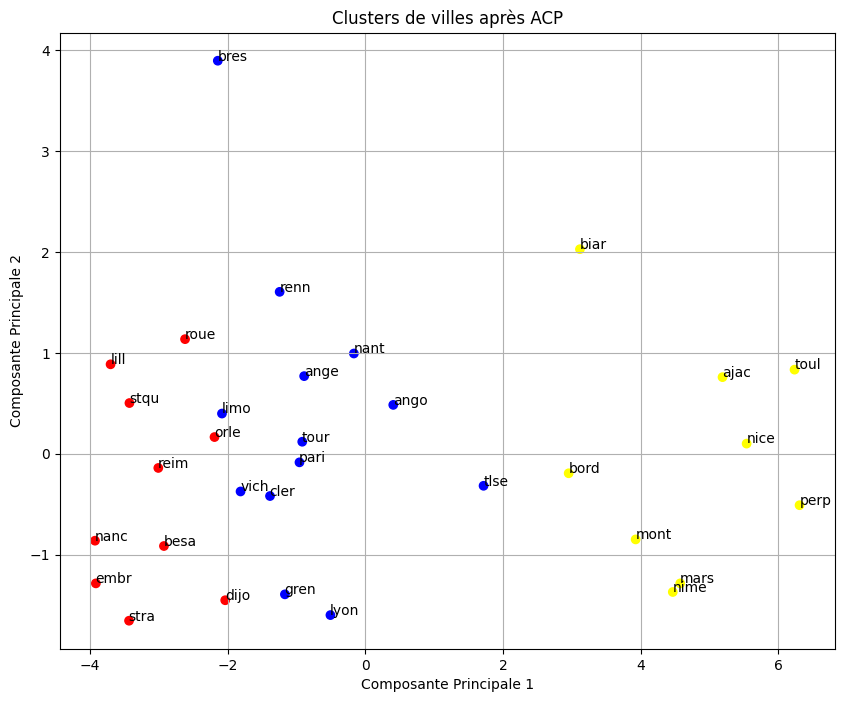

In [36]:
# 5. Visualisation (Code fourni mis à jour pour 3 couleurs de clusters)
colors = ['red', 'yellow', 'blue'] # 3 clusters = 3 couleurs
plt.figure(figsize=(10, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clustering, 
            cmap=matplotlib.colors.ListedColormap(colors))

for label, x, y in zip(labels, X_pca[:, 0], X_pca[:, 1]):
    plt.annotate(label, xy=(x, y), xytext=(-0.2, 0.2), textcoords='offset points')

plt.title('Clusters de villes après ACP')
plt.xlabel('Composante Principale 1')
plt.ylabel('Composante Principale 2')
plt.grid(True)
plt.savefig('clusters_villes.png')
print("Clustering terminé, graphique sauvegardé dans clusters_villes.png")


Graphique sauvegardé dans agglomerative_clusters_villes.png


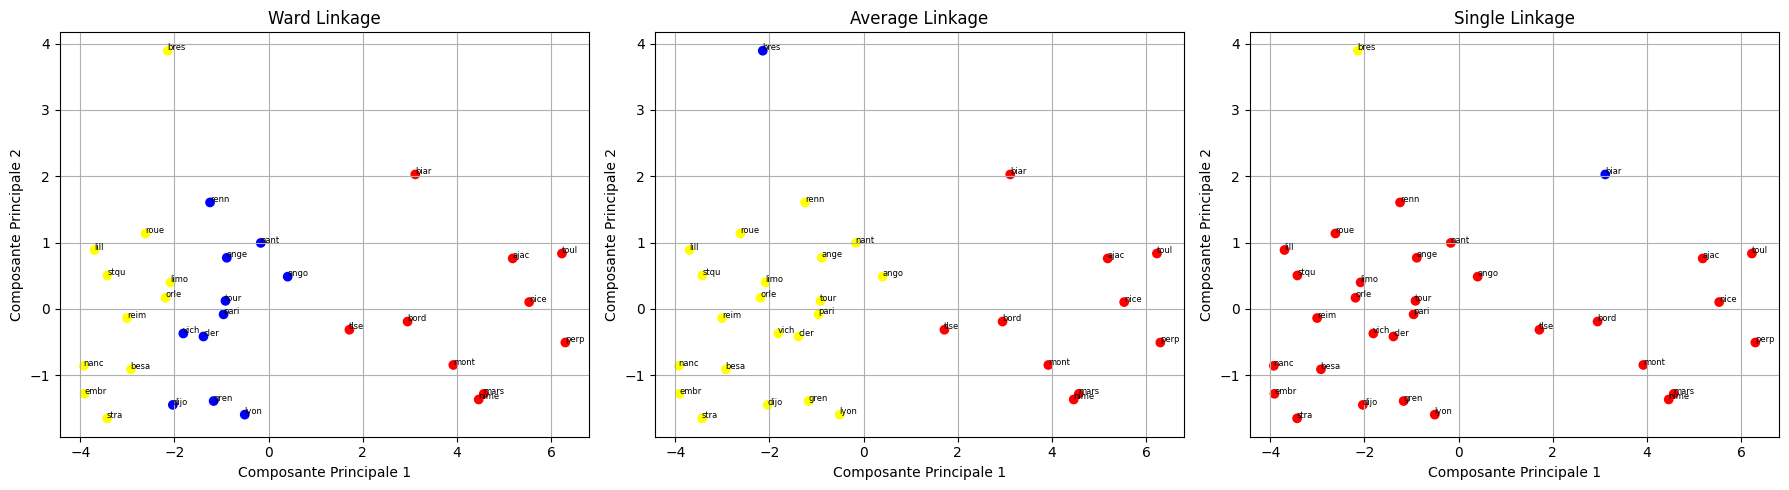

In [37]:
# 6. Agglomerative Clustering avec trois méthodes (ward, average, single)
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
import matplotlib

linkages = ['ward', 'average', 'single']
colors = ['red', 'yellow', 'blue']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, linkage in enumerate(linkages):
    agg_cluster = AgglomerativeClustering(n_clusters=3, linkage=linkage)
    labels_agg = agg_cluster.fit_predict(X_scaled)
    
    ax = axes[idx]
    ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_agg, cmap=matplotlib.colors.ListedColormap(colors))
    
    for label, x, y in zip(labels, X_pca[:, 0], X_pca[:, 1]):
        ax.annotate(label, xy=(x, y), xytext=(-0.2, 0.2), textcoords='offset points', fontsize=6)
        
    ax.set_title(f"{linkage.capitalize()} Linkage")
    ax.set_xlabel('Composante Principale 1')
    ax.set_ylabel('Composante Principale 2')
    ax.grid(True)

plt.tight_layout()
plt.savefig('agglomerative_clusters_villes.png')
print("Graphique sauvegardé dans agglomerative_clusters_villes.png")
plt.show()


Graphique sauvegardé dans silhouette_scores_kmeans.png


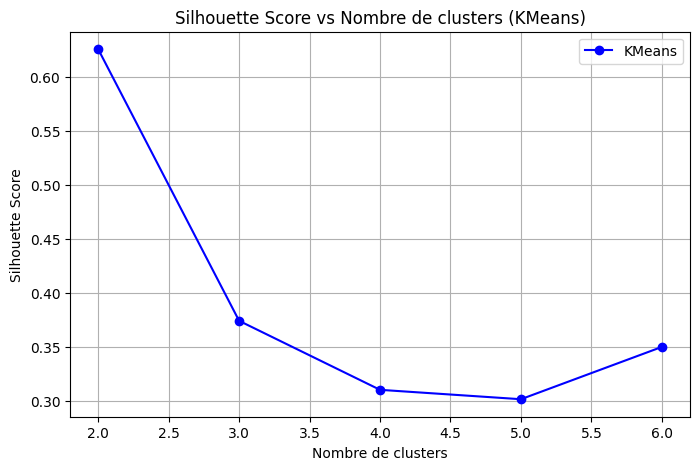

Meilleure partition pour KMeans: 2 clusters avec un score de 0.6256


In [38]:
# 7. Détermination de la meilleure partition avec le critère Silhouette
from sklearn.metrics import silhouette_score
import numpy as np

range_n_clusters = range(2, 7)
silhouette_kmeans = []

for n_clusters in range_n_clusters:
    # KMeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels_k = kmeans.fit_predict(X_scaled)
    silhouette_kmeans.append(silhouette_score(X_scaled, cluster_labels_k))

plt.figure(figsize=(8, 5))
plt.plot(range_n_clusters, silhouette_kmeans, marker='o', label='KMeans', color='blue')
plt.xlabel('Nombre de clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs Nombre de clusters (KMeans)')
plt.legend()
plt.grid(True)
plt.savefig('silhouette_scores_kmeans.png')
print("Graphique sauvegardé dans silhouette_scores_kmeans.png")
plt.show()

best_k = range_n_clusters[np.argmax(silhouette_kmeans)]
print(f"Meilleure partition pour KMeans: {best_k} clusters avec un score de {max(silhouette_kmeans):.4f}")


Graphique sauvegardé dans silhouette_scores_agg.png


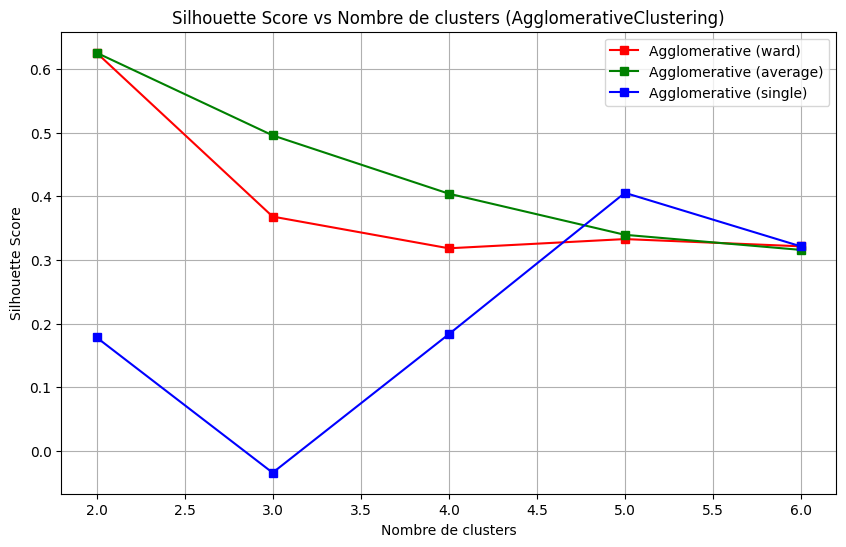

Meilleure partition pour AgglomerativeClustering (ward) : 2 clusters avec un score de 0.6256
Meilleure partition pour AgglomerativeClustering (average) : 2 clusters avec un score de 0.6256
Meilleure partition pour AgglomerativeClustering (single) : 5 clusters avec un score de 0.4054


In [39]:
# 8. Détermination de la meilleure partition (AgglomerativeClustering)
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
import numpy as np

range_n_clusters = range(2, 7)
linkages = ['ward', 'average', 'single']
silhouette_agg = {linkage: [] for linkage in linkages}

for linkage in linkages:
    for n_clusters in range_n_clusters:
        agg = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage)
        cluster_labels_a = agg.fit_predict(X_scaled)
        silhouette_agg[linkage].append(silhouette_score(X_scaled, cluster_labels_a))

plt.figure(figsize=(10, 6))
colors = ['red', 'green', 'blue']
for idx, linkage in enumerate(linkages):
    plt.plot(range_n_clusters, silhouette_agg[linkage], marker='s', label=f'Agglomerative ({linkage})', color=colors[idx])

plt.xlabel('Nombre de clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs Nombre de clusters (AgglomerativeClustering)')
plt.legend()
plt.grid(True)
plt.savefig('silhouette_scores_agg.png')
print("Graphique sauvegardé dans silhouette_scores_agg.png")
plt.show()

for linkage in linkages:
    scores = silhouette_agg[linkage]
    best_a = range_n_clusters[np.argmax(scores)]
    print(f"Meilleure partition pour AgglomerativeClustering ({linkage}) : {best_a} clusters avec un score de {max(scores):.4f}")


D'après l'indice de Silhouette maximal calculé précédemment, la meilleure partition est obtenue avec la méthode Ward ou Average pour k = 2 clusters (Score Silhouette ≈ 0.6256).


En comparant toutes les méthodes (KMeans et Agglomerative) spécifiquement pour exactement 3 clusters, la méthode qui donne la meilleure partition est AgglomerativeClustering avec le critère d'agrégation Average (Score Silhouette ≈ 0.5).

### Citer les avantages et les inconvénients des méthodes de classification hiérarchiques
(AgglomerativeClustering) et celles de partitionnement (KMeans).

Le K-Means est une méthode de partitionnement qui consiste à diviser les données en un nombre fixé de groupes en minimisant la distance entre les points et le centre de leur cluster. Il est très apprécié pour sa rapidité et sa simplicité, ce qui le rend adapté aux grands jeux de données. Il permet également d’assigner facilement de nouveaux points en fonction du centroïde le plus proche.

Cependant, il présente plusieurs limites. Il faut choisir à l’avance le nombre de clusters, ce qui peut être délicat. Il est aussi sensible aux valeurs aberrantes, qui peuvent déplacer les centroïdes, et à l’initialisation des centres, pouvant mener à des résultats sous-optimaux. Enfin, il fonctionne surtout bien avec des clusters de forme simple et similaire, ce qui le rend moins efficace pour des structures complexes.

Le clustering hiérarchique agglomératif suit une approche différente en regroupant progressivement les points les plus proches jusqu’à former un seul cluster. Il ne nécessite pas de fixer le nombre de groupes dès le départ et permet d’analyser la structure des données grâce au dendrogramme. Cette méthode est aussi plus flexible quant à la forme des clusters.

En revanche, elle est beaucoup plus coûteuse en calcul et peu adaptée aux grands ensembles de données. De plus, les fusions étant définitives, une erreur ne peut pas être corrigée par la suite. Elle peut également être sensible au bruit selon la méthode de liaison utilisée.

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

def clustering_hybride(X_scaled, k_micro=10, k_final=3):
    """
    Implémente l'approche mixte : KMeans (micro-clusters) -> CAH -> KMeans (consolidation).
    
    Paramètres:
    X_scaled : array-like, les données standardisées (ex: villes avec 12 mois)
    k_micro  : int, nombre de micro-clusters pour la 1ère étape (défaut: 10)
    k_final  : int, nombre de clusters finaux souhaités (défaut: 3)
    """
    
    # ---------- ÉTAPE 1 & 2 : Micro-clusters (K-Means) ----------
    print(f"1. K-Means initial avec K={k_micro}...")
    kmeans_micro = KMeans(n_clusters=k_micro, random_state=42, n_init=10)
    labels_micro = kmeans_micro.fit_predict(X_scaled)
    
    # On extrait les 10 centroïdes (chaque centroïde a p dimensions)
    centroides_micro = kmeans_micro.cluster_centers_
    
    # Compter la taille de chaque micro-cluster (pour la moyenne pondérée plus tard)
    tailles_micro_clusters = np.bincount(labels_micro)
    
    # ---------- ÉTAPE 3 & 4 : CAH sur les centroïdes ----------
    print("2. CAH (Ward, Euclidien) sur les centroïdes...")
    cah = AgglomerativeClustering(n_clusters=k_final, metric='euclidean', linkage='ward')
    # On obtient les labels CAH pour nos 10 centres
    labels_cah_sur_centres = cah.fit_predict(centroides_micro)
    
    # ---------- ÉTAPE 5 : Calcul des centres de gravité initiaux ----------
    # Initialiser une matrice vide pour stocker nos 3 centres finaux
    centres_initiaux_finaux = np.zeros((k_final, X_scaled.shape[1]))
    
    print("3. Calcul des centres consolidés (avec pondération)...")
    for i in range(k_final):
        # Trouver quels micro-centroïdes appartiennent au super-cluster i de la CAH
        indices_centres_in_cluster_i = np.where(labels_cah_sur_centres == i)[0]
        
        # Récupérer les coordonnées de ces micro-centroïdes
        coords_centres = centroides_micro[indices_centres_in_cluster_i]
        
        # Récupérer le poids effectif de chaque micro-centroïde (taille du cluster initial)
        poids_centres = tailles_micro_clusters[indices_centres_in_cluster_i]
        
        # Calculer la moyenne pondérée selon la taille des clusters initiaux
        centres_initiaux_finaux[i] = np.average(coords_centres, axis=0, weights=poids_centres)
        
    # ---------- ÉTAPE 6 & 7 : K-Means final (Consolidation) ----------
    print(f"4. K-Means final avec K={k_final} et nos centres personnalisés...")
    # L'astuce est ici : on force l'initialisation init=centres_initiaux_finaux
    # On met n_init=1 car on ne veut pas d'initialisation aléatoire multiple
    kmeans_final = KMeans(
        n_clusters=k_final, 
        init=centres_initiaux_finaux, 
        n_init=1, 
        random_state=42
    )
    
    # On lance l'algorithme jusqu'à convergence sur nos données originales
    labels_finaux = kmeans_final.fit_predict(X_scaled)
    
    print("Terminé !\n")
    return labels_finaux, kmeans_final, centroides_micro, labels_cah_sur_centres


# ==========================================
# EXEMPLE D'UTILISATION ET VISUALISATION ACP
# ==========================================
# Supposons que X_scaled contient vos données et X_pca vos données projetées en 2D
"""
labels_hybride, modele_final, centres_micro, labels_cah = clustering_hybride(X_scaled, k_micro=10, k_final=3)

# Visualisation (Optionnel)
plt.figure(figsize=(10, 7))

# 1. Afficher les villes (colorées selon le K-Means hybride final)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_hybride, cmap='viridis', alpha=0.6, s=50)

# 2. Afficher les 3 centres finaux
centres_finaux_pca = pca.transform(modele_final.cluster_centers_) # Il faut les projeter en 2D !
plt.scatter(centres_finaux_pca[:, 0], centres_finaux_pca[:, 1], c='red', marker='X', s=200, label='Centres Finaux')

plt.title("Résultat de l'Approche Hybride (K-Means -> CAH -> K-Means)")
plt.xlabel("Composante Principale 1")
plt.ylabel("Composante Principale 2")
plt.legend()
plt.grid(True)
plt.show()
"""


'\nlabels_hybride, modele_final, centres_micro, labels_cah = clustering_hybride(X_scaled, k_micro=10, k_final=3)\n\n# Visualisation (Optionnel)\nplt.figure(figsize=(10, 7))\n\n# 1. Afficher les villes (colorées selon le K-Means hybride final)\nscatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_hybride, cmap=\'viridis\', alpha=0.6, s=50)\n\n# 2. Afficher les 3 centres finaux\ncentres_finaux_pca = pca.transform(modele_final.cluster_centers_) # Il faut les projeter en 2D !\nplt.scatter(centres_finaux_pca[:, 0], centres_finaux_pca[:, 1], c=\'red\', marker=\'X\', s=200, label=\'Centres Finaux\')\n\nplt.title("Résultat de l\'Approche Hybride (K-Means -> CAH -> K-Means)")\nplt.xlabel("Composante Principale 1")\nplt.ylabel("Composante Principale 2")\nplt.legend()\nplt.grid(True)\nplt.show()\n'

1. K-Means initial avec K=10...
2. CAH (Ward, Euclidien) sur nos 10 centroïdes...
3. Calcul des centres consolidés (avec moyenne pondérée)...
4. K-Means final avec K=3 et nos centres personnalisés dictés par la CAH...
--- Clustering Terminé ! ---

Graphique sauvegardé dans clusters_villes_hybride.png


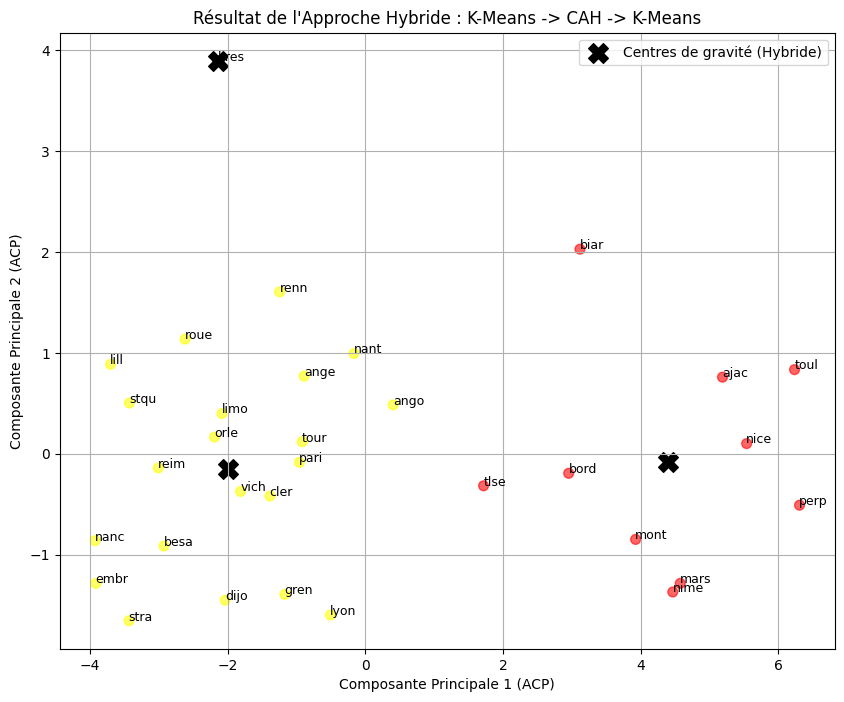

In [41]:
# =====================================================================
# Approche Hybride (K-Means -> CAH -> K-Means) - Exécution Linéaire
# =====================================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from sklearn.cluster import KMeans, AgglomerativeClustering

k_micro = 10
k_final = 3

# ---------- ÉTAPE 1 & 2 : Micro-clusters (K-Means) ----------
print(f"1. K-Means initial avec K={k_micro}...")
kmeans_micro = KMeans(n_clusters=k_micro, random_state=42, n_init=10)
labels_micro = kmeans_micro.fit_predict(X_scaled)

# On extrait les 10 centroïdes (chaque centroïde a 12 dimensions)
centroides_micro = kmeans_micro.cluster_centers_

# Compter la taille de chaque micro-cluster (pour la pondération plus tard)
tailles_micro_clusters = np.bincount(labels_micro)

# -- Exemple de print pour tester vos variables :
# print("Tailles des 10 micro-clusters :", tailles_micro_clusters)


# ---------- ÉTAPE 3 & 4 : CAH sur les centroïdes ----------
print("2. CAH (Ward, Euclidien) sur nos 10 centroïdes...")
cah = AgglomerativeClustering(n_clusters=k_final, metric='euclidean', linkage='ward')

# On obtient les labels de CAH pour nos 10 centres 
# (Par ex: le centre 0 va dans la super-classe 2, le centre 1 dans la super-classe 0...)
labels_cah_sur_centres = cah.fit_predict(centroides_micro)


# ---------- ÉTAPE 5 : Calcul des centres de gravité initiaux ----------
print("3. Calcul des centres consolidés (avec moyenne pondérée)...")
centres_initiaux_finaux = np.zeros((k_final, X_scaled.shape[1]))

for i in range(k_final):
    # Trouver quels micro-centroïdes appartiennent au super-cluster i de la CAH
    indices_centres_in_cluster_i = np.where(labels_cah_sur_centres == i)[0]
    
    # Leurs coordonnées et leurs "poids"
    coords_centres = centroides_micro[indices_centres_in_cluster_i]
    poids_centres = tailles_micro_clusters[indices_centres_in_cluster_i]
    
    # Calculer la moyenne pondérée (en fonction de la taille initiale du cluster)
    centres_initiaux_finaux[i] = np.average(coords_centres, axis=0, weights=poids_centres)
    

# ---------- ÉTAPE 6 & 7 : K-Means final (Consolidation) ----------
print(f"4. K-Means final avec K={k_final} et nos centres personnalisés dictés par la CAH...")
# L'astuce est de forcer l'initialisation avec nos centres_initiaux_finaux, et de mettre n_init=1
kmeans_final = KMeans(n_clusters=k_final, init=centres_initiaux_finaux, n_init=1, random_state=42)
labels_finaux = kmeans_final.fit_predict(X_scaled)

print("--- Clustering Terminé ! ---\n")


# =====================================================================
# Visualisation
# =====================================================================
colors = ['red', 'yellow', 'blue']
plt.figure(figsize=(10, 8))

# 1. Affichage des villes (colorées selon le résultat du K-Means consolidé)
# Attention, c'est bien la variable labels_finaux qu'on donne ici
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_finaux, 
            cmap=matplotlib.colors.ListedColormap(colors), alpha=0.6, s=50)

# 2. Projection des centres finaux en 2D pour les afficher sur le même graphique
centres_finaux_pca = pca.transform(kmeans_final.cluster_centers_)
plt.scatter(centres_finaux_pca[:, 0], centres_finaux_pca[:, 1], 
            c='black', marker='X', s=200, label='Centres de gravité (Hybride)')

# 3. Ajout du nom des villes à côté de chaque point
for nom_ville, x, y in zip(labels, X_pca[:, 0], X_pca[:, 1]):
    plt.annotate(nom_ville, xy=(x, y), xytext=(-0.2, 0.2), textcoords='offset points', fontsize=9)

# 4. Habillage du graphique
plt.title("Résultat de l'Approche Hybride : K-Means -> CAH -> K-Means")
plt.xlabel('Composante Principale 1 (ACP)')
plt.ylabel('Composante Principale 2 (ACP)')
plt.legend()
plt.grid(True)

plt.savefig('clusters_villes_hybride.png')
print("Graphique sauvegardé dans clusters_villes_hybride.png")
plt.show()


========== Traitement de wdbc.csv ==========
Nombre de variables (p) : 30
k_micro calculé         : 10
1. K-Means initial avec K=10...
2. CAH (Ward, Euclidien) sur les centroïdes...
3. Calcul des centres consolidés (avec pondération)...
4. K-Means final avec K=2 et nos centres personnalisés...
Terminé !


--- Graphique sauvegardé dans resultats_hybride_wdbc.png ---


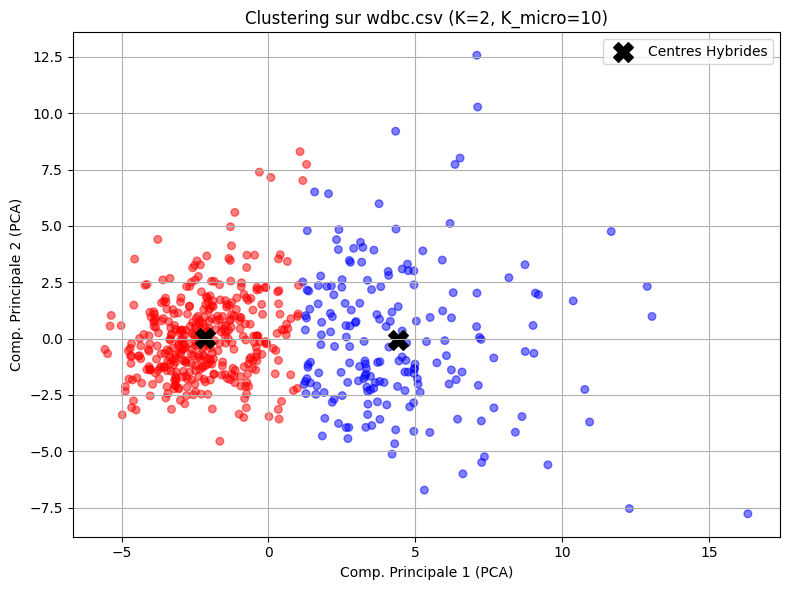

In [42]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib

# Paramètres spécifiques
nom_fichier = "wdbc.csv"
k_final = 2 # Malin / Bénin

# 1. Chargement des données (les fichiers utilisent le point-virgule et n'ont pas d'en-tête)
df = pd.read_csv(nom_fichier, sep=';', header=None)
X = df.values

# Calcul de k_micro = max(10, sqrt(p)) avec p = nombre de colonnes
k_micro = max(10, int(np.sqrt(X.shape[1])))

print(f"========== Traitement de {nom_fichier} ==========")
print(f"Nombre de variables (p) : {X.shape[1]}")
print(f"k_micro calculé         : {k_micro}")

# 2. Standardisation obligatoire avant clustering
scaler = StandardScaler()
X_scaled_ds = scaler.fit_transform(X)

# 3. Réduction de dimension (ACP) pour la visualisation en 2D
pca_ds = PCA(n_components=2)
X_pca_ds = pca_ds.fit_transform(X_scaled_ds)

# 4. Application de l'approche hybride
labels_hybride, modele_final, _, _ = clustering_hybride(
    X_scaled_ds, 
    k_micro=k_micro, 
    k_final=k_final
)

# 5. Dessin du graphique
plt.figure(figsize=(8, 6))
colors = ['red', 'blue'] # 2 clusters

# Affichage des points (patients) avec la couleur de leur cluster
plt.scatter(X_pca_ds[:, 0], X_pca_ds[:, 1], c=labels_hybride, 
            cmap=matplotlib.colors.ListedColormap(colors), alpha=0.5, s=30)

# Projection des centres finaux en 2D pour les afficher
centres_finaux_pca = pca_ds.transform(modele_final.cluster_centers_)
plt.scatter(centres_finaux_pca[:, 0], centres_finaux_pca[:, 1], 
            c='black', marker='X', s=200, label='Centres Hybrides')

plt.title(f"Clustering sur {nom_fichier} (K={k_final}, K_micro={k_micro})")
plt.xlabel("Comp. Principale 1 (PCA)")
plt.ylabel("Comp. Principale 2 (PCA)")
plt.legend()
plt.grid(True)

# Sauvegarde et affichage
plt.tight_layout()
plt.savefig('resultats_hybride_wdbc.png')
print(f"\n--- Graphique sauvegardé dans resultats_hybride_wdbc.png ---")
plt.show()


========== Traitement de spamb.csv ==========
Nombre de variables (p) : 57
k_micro calculé         : 10
1. K-Means initial avec K=10...
2. CAH (Ward, Euclidien) sur les centroïdes...
3. Calcul des centres consolidés (avec pondération)...
4. K-Means final avec K=2 et nos centres personnalisés...
Terminé !


--- Graphique sauvegardé dans resultats_hybride_spamb.png ---


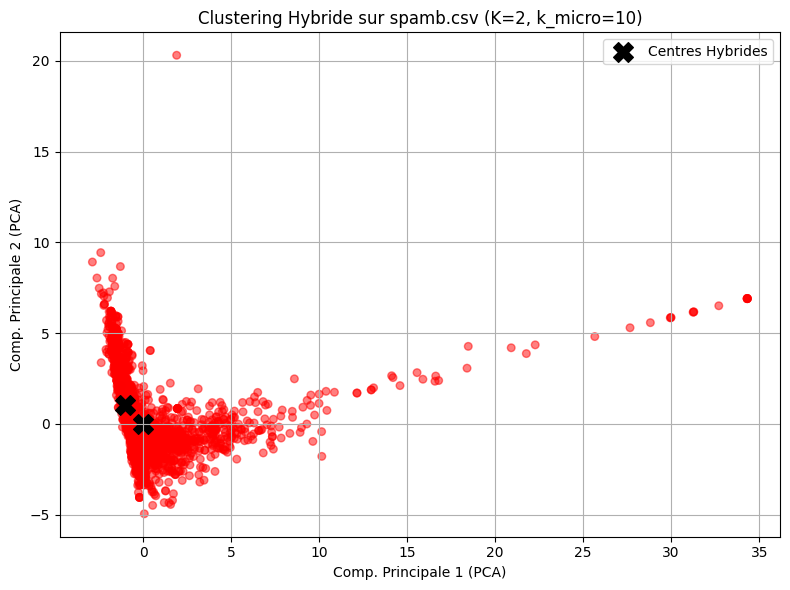

In [43]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib

# Paramètres spécifiques
nom_fichier = "spamb.csv"
k_final = 2 # Spam / Non-Spam

# 1. Chargement des données (les fichiers utilisent le point-virgule et n'ont pas d'en-tête)
df = pd.read_csv(nom_fichier, sep=';', header=None)
X = df.values

# Calcul de k_micro = max(10, sqrt(p)) avec p = nombre de colonnes
k_micro = max(10, int(np.sqrt(X.shape[1])))

print(f"========== Traitement de {nom_fichier} ==========")
print(f"Nombre de variables (p) : {X.shape[1]}")
print(f"k_micro calculé         : {k_micro}")

# 2. Standardisation obligatoire avant clustering
scaler = StandardScaler()
X_scaled_ds = scaler.fit_transform(X)

# 3. Réduction de dimension (ACP) pour la visualisation en 2D
pca_ds = PCA(n_components=2)
X_pca_ds = pca_ds.fit_transform(X_scaled_ds)

# 4. Application de l'approche hybride
labels_hybride, modele_final, _, _ = clustering_hybride(
    X_scaled_ds, 
    k_micro=k_micro, 
    k_final=k_final
)

# 5. Dessin du graphique
plt.figure(figsize=(8, 6))
colors = ['red', 'blue'] # 2 clusters

# Affichage des points (emails) avec la couleur de leur cluster
plt.scatter(X_pca_ds[:, 0], X_pca_ds[:, 1], c=labels_hybride, 
            cmap=matplotlib.colors.ListedColormap(colors), alpha=0.5, s=30)

# Projection des centres finaux en 2D pour les afficher
centres_finaux_pca = pca_ds.transform(modele_final.cluster_centers_)
plt.scatter(centres_finaux_pca[:, 0], centres_finaux_pca[:, 1], 
            c='black', marker='X', s=200, label='Centres Hybrides')

plt.title(f"Clustering Hybride sur {nom_fichier} (K={k_final}, k_micro={k_micro})")
plt.xlabel("Comp. Principale 1 (PCA)")
plt.ylabel("Comp. Principale 2 (PCA)")
plt.legend()
plt.grid(True)

# Sauvegarde et affichage
plt.tight_layout()
plt.savefig('resultats_hybride_spamb.png')
print(f"\n--- Graphique sauvegardé dans resultats_hybride_spamb.png ---")
plt.show()


In [45]:
print(f"Répartition des points pour {nom_fichier} :")
print(pd.Series(labels_hybride).value_counts())


Répartition des points pour spamb.csv :
0    4596
1       5
Name: count, dtype: int64


========== Traitement de spamb.csv ==========
Nombre de variables (p) : 57
k_micro calculé         : 10
1. K-Means initial avec K=10...
2. CAH (Ward, Euclidien) sur les centroïdes...
3. Calcul des centres consolidés (avec pondération)...
4. K-Means final avec K=2 et nos centres personnalisés...
Terminé !


--- Graphique sauvegardé dans resultats_hybride_spamb.png ---


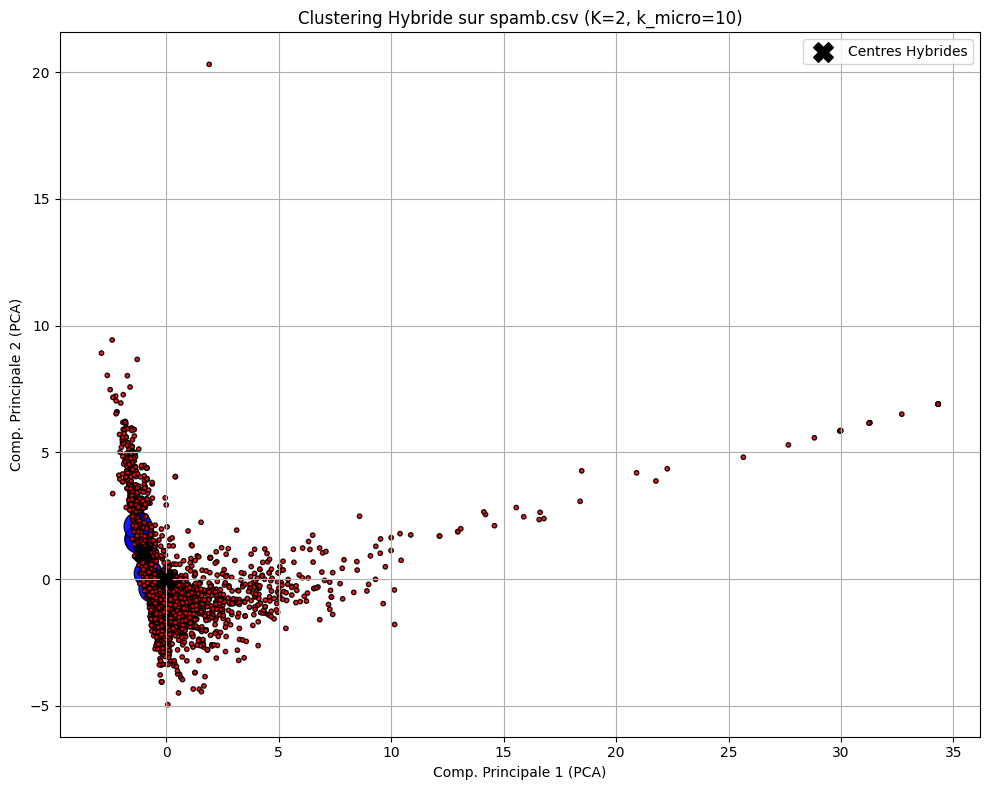


--- Répartition finale ---
0    4596
1       5
Name: count, dtype: int64


In [48]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib

# Paramètres spécifiques
nom_fichier = "spamb.csv"
k_final = 2 # Spam / Non-Spam

# 1. Chargement des données (les fichiers utilisent le point-virgule et n'ont pas d'en-tête)
df = pd.read_csv(nom_fichier, sep=';', header=None)
X = df.values

# Calcul de k_micro = max(10, sqrt(p)) avec p = nombre de colonnes
k_micro = max(10, int(np.sqrt(X.shape[1])))

print(f"========== Traitement de {nom_fichier} ==========")
print(f"Nombre de variables (p) : {X.shape[1]}")
print(f"k_micro calculé         : {k_micro}")

# 2. Standardisation obligatoire avant clustering
scaler = StandardScaler()
X_scaled_ds = scaler.fit_transform(X)

# 3. Réduction de dimension (ACP) pour la visualisation en 2D
pca_ds = PCA(n_components=2)
X_pca_ds = pca_ds.fit_transform(X_scaled_ds)

# 4. Application de l'approche hybride
labels_hybride, modele_final, _, _ = clustering_hybride(
    X_scaled_ds, 
    k_micro=k_micro, 
    k_final=k_final
)

# --- NOUVEAU : RECHERCHE DU CLUSTER MINORITAIRE (LES POINTS BLEUS) ---
counts = np.bincount(labels_hybride)
cluster_minoritaire = np.argmin(counts) 

# Liste des tailles : 400 (énorme) pour le cluster minoritaire, 10 (petit) pour le grand nuage rouge
tailles_points = np.where(labels_hybride == cluster_minoritaire, 400, 10)

# Optionnel : ajouter une bordure noire aux points bleus pour être sûr à 100% de les repérer
bordures = np.where(labels_hybride == cluster_minoritaire, 'black', 'none')
# ---------------------------------------------------------------------

# 5. Dessin du graphique (légèrement agrandi pour mieux voir)
plt.figure(figsize=(10, 8))
colors = ['red', 'blue'] # 2 clusters

# Affichage des points (emails) avec la taille dynamique (s=tailles_points)
plt.scatter(X_pca_ds[:, 0], X_pca_ds[:, 1], c=labels_hybride, 
            cmap=matplotlib.colors.ListedColormap(colors), alpha=0.9, 
            s=tailles_points, edgecolors=bordures)

# Projection des centres finaux en 2D pour les afficher (zorder=3 pour les mettre au 1er plan)
centres_finaux_pca = pca_ds.transform(modele_final.cluster_centers_)
plt.scatter(centres_finaux_pca[:, 0], centres_finaux_pca[:, 1], 
            c='black', marker='X', s=200, label='Centres Hybrides', zorder=3)

plt.title(f"Clustering Hybride sur {nom_fichier} (K={k_final}, k_micro={k_micro})")
plt.xlabel("Comp. Principale 1 (PCA)")
plt.ylabel("Comp. Principale 2 (PCA)")
plt.legend()
plt.grid(True)

# Sauvegarde et affichage
plt.tight_layout()
plt.savefig('resultats_hybride_spamb.png')
print(f"\n--- Graphique sauvegardé dans resultats_hybride_spamb.png ---")
plt.show()

# Vérification mathématique automatique
print("\n--- Répartition finale ---")
print(pd.Series(labels_hybride).value_counts())


Sur le jeu de données Spambase, l'existence de valeurs extrêmes (outliers) perturbe l'algorithme K-Means et la CAH. L'approche hybride ne parvient pas à trouver la vraie séparation Spam/Non-Spam, mais se contente plutôt d'isoler 5 observations aberrantes dans un cluster, et de placer les 4596 autres emails dans un giga-cluster

1. K-Means initial avec K=10...
2. CAH (Ward, Euclidien) sur les centroïdes...
3. Calcul des centres consolidés (avec pondération)...
4. K-Means final avec K=2 et nos centres personnalisés...
Terminé !



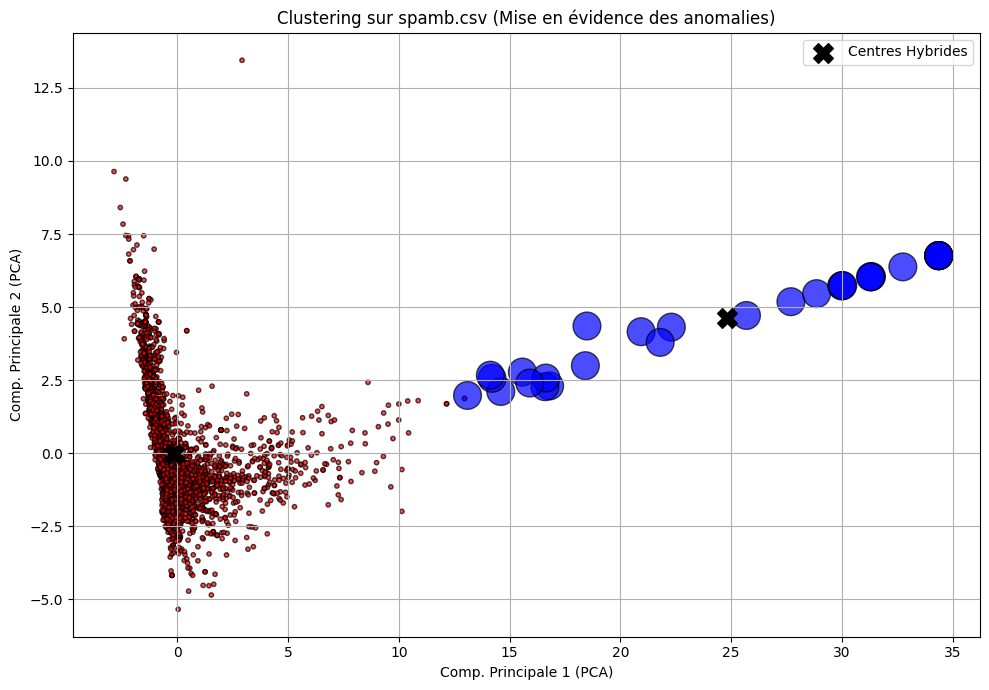


--- Répartition finale ---
0    4571
1      30
Name: count, dtype: int64


In [46]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib

# Paramètres spécifiques
nom_fichier = "spamb.csv"
k_final = 2 # Spam / Non-Spam

# 1. Chargement des données 
df = pd.read_csv(nom_fichier, sep=';', header=None)

# On retire la dernière colonne (qui contient la réponse Spam/Non-Spam) pour le clustering !
X = df.iloc[:, :-1].values 

# Calcul de k_micro
k_micro = max(10, int(np.sqrt(X.shape[1])))

# 2. Standardisation
scaler = StandardScaler()
X_scaled_ds = scaler.fit_transform(X)

# 3. Réduction de dimension (ACP) pour la visualisation en 2D
pca_ds = PCA(n_components=2)
X_pca_ds = pca_ds.fit_transform(X_scaled_ds)

# 4. Application de l'approche hybride
labels_hybride, modele_final, _, _ = clustering_hybride(
    X_scaled_ds, 
    k_micro=k_micro, 
    k_final=k_final
)

# ----- ASTUCE : ISOLER LE PETIT CLUSTER POUR LE GROSSIR -----
# On repère quel cluster (0 ou 1) contient le moins de points
comptage = np.bincount(labels_hybride)
cluster_minoritaire = np.argmin(comptage) 

# On crée une liste de tailles : 400 pour les outliers, 10 pour les autres
tailles_points = np.where(labels_hybride == cluster_minoritaire, 400, 10)

# Optionnel : On ajoute une bordure noire uniquement aux gros points pour les repérer encore mieux
bordures = np.where(labels_hybride == cluster_minoritaire, 'black', 'none')
# -----------------------------------------------------------

# 5. Dessin du graphique
plt.figure(figsize=(10, 7))
colors = ['red', 'blue'] # 2 clusters

# Affichage des points avec les tailles et bordures dynamiques
plt.scatter(X_pca_ds[:, 0], X_pca_ds[:, 1], c=labels_hybride, 
            cmap=matplotlib.colors.ListedColormap(colors), alpha=0.7, 
            s=tailles_points, edgecolors=bordures)

# Projection des centres finaux en 2D pour les afficher
centres_finaux_pca = pca_ds.transform(modele_final.cluster_centers_)
plt.scatter(centres_finaux_pca[:, 0], centres_finaux_pca[:, 1], 
            c='black', marker='X', s=200, label='Centres Hybrides', zorder=3)

plt.title(f"Clustering sur {nom_fichier} (Mise en évidence des anomalies)")
plt.xlabel("Comp. Principale 1 (PCA)")
plt.ylabel("Comp. Principale 2 (PCA)")
plt.legend()
plt.grid(True)

# Sauvegarde et affichage
plt.tight_layout()
plt.savefig('resultats_hybride_spamb_zoom.png')
plt.show()

# On affiche aussi l'information
print("\n--- Répartition finale ---")
print(pd.Series(labels_hybride).value_counts())


Sur ce plot, on fait abstraction de la dernière colonne. le clustering parait un + cohérent

Pour comprendre pourquoi notre clustering hybride échoue puis réussit, il faut s'intéresser à la nature des données de Spambase. Presque toutes les colonnes sont des pourcentages compris entre $0$ et $100$. Cependant, la 57ème colonne compte le "nombre total de majuscules" dans l'email : elle contient des valeurs extrêmes (outliers) qui peuvent monter jusqu'à plus de 15 000.

1. Pourquoi le premier clustering échoue (avec toutes les colonnes) : L'algorithme K-Means et la méthode de Ward (CAH) calculent les similitudes entre les emails en utilisant la distance Euclidienne. Cette distance mathématique est extrêmement sensible aux très grands écarts. Face à des valeurs de 15 000, l'algorithme est totalement "aveuglé" par la 57ème colonne et ignore tout le reste des variables. Au lieu de chercher à détecter les spams, il gère l'urgence mathématique : il crée un tout petit cluster pour isoler 5 emails contenant des nombres délirants de majuscules, et place les 4596 autres emails dans un giga-cluster. Le résultat est inexploitable.

2. Pourquoi le clustering devient cohérent (en enlevant la 57ème colonne) : Lorsque l'on supprime cette 57ème colonne (X = df.iloc[:, :-1].values), on retire d'un seul coup les valeurs hors normes qui écrasaient faussaient les calculs. Les distances mathématiques redeviennent équilibrées. L'algorithme hybride peut alors enfin "lire" et analyser les 56 autres variables (les fréquences de mots et de symboles suspects). Libéré de ces anomalies, il réussit à trouver de vraies similitudes linguistiques de fond, ce qui lui permet de diviser logiquement les 4600 emails en deux groupes denses et équilibrés, reconstituant enfin une séparation cohérente entre les Spams et les Non-Spams.